In [1010]:
import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt


import pymc as pm
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib
from collections import Counter
import collections
import random
from tqdm import tqdm
from scipy.special import expit

## Utils


In [ ]:
def clean_data(players_preds, valid_player_ids):
    print('starting to clean data...')
    players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
    print(players_preds['fpl_id'])
    print(players_preds.shape, len(valid_player_ids))
    gk_data = players_preds[players_preds['position'] == 'GK'][data_cols_gk]
    def_data = players_preds[players_preds['position'] == 'DEF'][data_cols]
    mid_data = players_preds[players_preds['position'] == 'MID'][data_cols].dropna()
    fwd_data = players_preds[players_preds['position'] == 'FWD'][data_cols].dropna()
    data = [gk_data, def_data, mid_data, fwd_data]

    # Get attributes
    g_prices = gk_data['value'].tolist() #*10
    d_prices = def_data['value'].tolist() #*10
    m_prices = mid_data['value'].tolist() #*10
    f_prices = fwd_data['value'].tolist() #*10
    prices = [g_prices, d_prices, m_prices, f_prices]
    # print(g_prices, len(d_prices), len(m_prices), len(f_prices))
    # print(len(g_prices), len(d_prices), len(m_prices), len(f_prices))

    g_xPts = players_preds[players_preds['position'] == 'GK']['xP_preds'].tolist()
    d_xPts = players_preds[players_preds['position'] == 'DEF']['xP_preds'].tolist()
    m_xPts = players_preds[players_preds['position'] == 'MID']['xP_preds'].tolist()
    f_xPts = players_preds[players_preds['position'] == 'FWD']['xP_preds'].tolist()
    xPts = [g_xPts, d_xPts, m_xPts, f_xPts]

    g_teams = players_preds[players_preds['position'] == 'GK']['player_team'].tolist()
    d_teams = players_preds[players_preds['position'] == 'DEF']['player_team'].tolist()
    m_teams = players_preds[players_preds['position'] == 'MID']['player_team'].tolist()
    f_teams = players_preds[players_preds['position'] == 'FWD']['player_team'].tolist()
    teams = [g_teams, d_teams, m_teams, f_teams]

    g_positions = players_preds[players_preds['position'] == 'GK']['position'].tolist()
    d_positions = players_preds[players_preds['position'] == 'DEF']['position'].tolist()
    m_positions = players_preds[players_preds['position'] == 'MID']['position'].tolist()
    f_positions = players_preds[players_preds['position'] == 'FWD']['position'].tolist()
    positions = [g_positions, d_positions, m_positions, f_positions]

    g_ids = players_preds[players_preds['position'] == 'GK']['FPL_ID'].tolist()
    d_ids = players_preds[players_preds['position'] == 'DEF']['FPL_ID'].tolist()
    m_ids = players_preds[players_preds['position'] == 'MID']['FPL_ID'].tolist()
    f_ids = players_preds[players_preds['position'] == 'FWD']['FPL_ID'].tolist()
    ids = [g_ids, d_ids, m_ids, f_ids]

    gk_data = gk_data.select_dtypes(include=[np.number])
    gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

    def_data = def_data.select_dtypes(include=[np.number])
    # Data
    def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

    mid_data = mid_data.select_dtypes(include=[np.number])
    mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

    fwd_data = fwd_data.select_dtypes(include=[np.number])
    fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

    # Selection percentages
    gk_select_by = gk_data['ownership_percent']
    def_select_by = def_data['ownership_percent']
    mid_select_by = mid_data['ownership_percent']
    fwd_select_by = fwd_data['ownership_percent']

    # Normalise the select_percts to get the working probs
    gk_probs = gk_select_by/np.sum(gk_select_by)
    def_probs = def_select_by/np.sum(def_select_by)
    mid_probs = mid_select_by/np.sum(mid_select_by)
    fwd_probs = fwd_select_by/np.sum(fwd_select_by)

    # 1. Define a small constant (epsilon) to replace the zeros
    epsilon = 1e-9 # A very small number

    # 2. Replace all zeros with this small number
    gk_probs[gk_probs == 0] = epsilon
    def_probs[def_probs == 0] = epsilon
    mid_probs[mid_probs == 0] = epsilon
    fwd_probs[fwd_probs == 0] = epsilon



    gk_data = gk_data.drop(columns='ownership_percent')
    def_data = def_data.drop(columns='ownership_percent')
    mid_data = mid_data.drop(columns='ownership_percent')
    fwd_data = fwd_data.drop(columns='ownership_percent')


    # # Make sure there are no nan or inf
    # def clean_array(arr):
    #     arr = np.nan_to_num(arr, nan=0.0, posinf=1e6, neginf=-1e6)
    #     return arr

    # gk_data  = clean_array(gk_data)
    # def_data = clean_array(def_data)
    # mid_data = clean_array(mid_data)
    # fwd_data = clean_array(fwd_data)

    X_gk = scaler_gk.transform(gk_data.values)
    X_def = scaler_def.transform(def_data.values)
    X_mid = scaler_mid.transform(mid_data.values)
    X_fwd = scaler_fwd.transform(fwd_data.values)


    # 3. Fit PCA and transform
    X_gk_pca = pd.DataFrame(pca_gk.transform(X_gk))
    X_def_pca = pd.DataFrame(pca_def.transform(X_def))
    X_mid_pca = pd.DataFrame(pca_mid.transform(X_mid))
    X_fwd_pca = pd.DataFrame(pca_fwd.transform(X_fwd))

    X_pca = [X_gk_pca, X_def_pca, X_mid_pca, X_fwd_pca]

    print('data successfully cleaned...')

    return data, prices, xPts, positions ,teams, ids, X_pca

def generate_probs(X_pca, betas):
    print('starting to generate selction probabilities')
    def safe_alpha(X_pca, beta):
        raw_scores = pm.math.dot(X_pca, beta.T)
        raw_scores -= pm.math.max(raw_scores)
        alpha = pm.math.exp(raw_scores) + 1e-3
        alpha = pm.math.clip(alpha, 1e-3, 1e3)
        return alpha


    alpha_g = safe_alpha(X_pca[0], betas[0].T)
    alpha_d = safe_alpha(X_pca[1], betas[1].T)
    alpha_m = safe_alpha(X_pca[2], betas[2].T)
    alpha_f = safe_alpha(X_pca[3], betas[3].T)

    with pm.Model():
        pg = pm.Dirichlet("pg", a=alpha_g)  # Ensure correct shape
        pd_ = pm.Dirichlet("pd_", a=alpha_d)  # Ensure correct shape
        pmid = pm.Dirichlet("pm", a=alpha_m)  # Ensure correct shape
        pf = pm.Dirichlet("pf", a=alpha_f)  # Ensure correct shape

        trace = pm.sample()

    # Extract posterior means
    pgk, pdef, pmid, pfwd = (
        trace.posterior["pg"].mean(dim=("chain", "draw")).values,
        trace.posterior["pd_"].mean(dim=("chain", "draw")).values,
        trace.posterior["pm"].mean(dim=("chain", "draw")).values,
        trace.posterior["pf"].mean(dim=("chain", "draw")).values)

    return pgk, pdef, pmid, pfwd

def is_feasible(portfolio, budget, budget_lower_bound, costs, stacker, teams):
    """
    Placeholder function to check if a portfolio is feasible.
    [span_6](start_span)[span_7](start_span)This checks the budget constraint and other linear constraints represented by W[span_6](end_span)[span_7](end_span).
    In a real scenario, this would include checks for positional limits (e.g., exactly 1 QB).
    """


    costs_ = []
    for sublist in costs:
        costs_.extend(sublist)

    costs = costs_

    total_cost = np.dot(portfolio, costs)
    # teams = pd.concat(teams).values
    # print(teams)
    if total_cost > budget or total_cost < budget_lower_bound:
        return False
    # Add other positional/diversity constraint checks here

    if stacker:
        pass

        # # Find which players are picked
        # chosen_indices = np.where(portfolio == 1)[0]
        # chosen_teams = [teams[i] for i in chosen_indices]

        # # Count team occurrences
        # team_counts = {}
        # for t in chosen_teams:
        #     team_counts[t] = team_counts.get(t, 0) + 1

        # # If no stack exists, force it by replacing one player
        # if max(team_counts.values()) < 2:
        #     # e.g. pick a random team among chosen ones and add another from it
        #     target_team = np.random.choice(chosen_teams)
        #     same_team_indices = [i for i, t in enumerate(teams) if t == target_team]

        #     # try adding one more player from that team (if not already chosen)
        #     for idx in same_team_indices:
        #         if portfolio[idx] == 0:
        #             portfolio[idx] = 1
        #             # then drop a random other player to keep total = 11
        #             other_idx = np.random.choice(chosen_indices)
        #             portfolio[other_idx] = 0
        #             break


    # --- Max 3 players per team ---
    team_counts = {}
    teams_ = []
    for sublist in teams:
        teams_.extend(sublist)

    teams = teams_

    team_idx = [idx for idx, _ in enumerate(portfolio) if portfolio[idx] == 1]
    selected_teams = [teams[i] for i in team_idx]

    if any(team >=3 for team in Counter(selected_teams).values()):
        return False
    print(total_cost)
    return True

def sample_opponent_portfolios(O, beta_estimates, feature_matrices, costs, budget, teams, xp_preds, q=0.35, Blb_ratio=0.90):
    """
    Args:
        O (int): Number of opponent portfolios to generate.
        beta_estimates (dict): A dictionary mapping position ('QB', 'RB', etc.) to its estimated beta coefficients.
        feature_matrices (dict): A dictionary mapping position to its feature matrix X.
        costs (np.ndarray): An array of costs for all players.
        budget (float): The total salary cap.
        q (float): The probability of a "stacker" contestant.
        Blb_ratio (float): The minimum budget usage ratio.

    Returns:
        list: A list of O feasible opponent portfolios (as numpy arrays).
    """
    xp_pred = {
        'GK': xp_preds[0],
        'DEF': xp_preds[1],
        'MID': xp_preds[2],
        'FWD': xp_preds[3],
    }

    positional_teams = {
        'GK': teams[0],
        'DEF': teams[1],
        'MID': teams[2],
        'FWD': teams[3],
    }

    alphas = {
        'GK': np.exp(np.dot(feature_matrices[0], beta_estimates['GK'])),
        'DEF': np.exp(np.dot(feature_matrices[1], beta_estimates['DEF'])),
        'MID': np.exp(np.dot(feature_matrices[2], beta_estimates['MID'])),
        'FWD': np.exp(np.dot(feature_matrices[3], beta_estimates['FWD']) )
    }
    # --- Step 2: Sample p vectors from Dirichlet distributions ---
    # [span_12](start_span)p ~ Dir(alpha) for each position[span_12](end_span)
    p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}

    opponent_portfolios = set()
    attempts = 0
    max_attempts = O * 50  # prevents infinite loop



    print(f"\nGenerating {O} opponent portfolios...")

    # --- Step 3-18: Main loop to generate O portfolios ---
    for _ in range(O):
        reject = True

        while reject:
            def get_random_fpl_formation():
                """
                Generates all valid 11-player FPL formations and returns one at random.
                """
                def_sizes = [3, 4, 5]
                mid_sizes = [2, 3, 4, 5]
                fwd_sizes = [1, 2, 3]

                valid_formations = []

                # Iterate through all combinations to find those that sum to 10 (plus 1 GK)
                for def_ in def_sizes:
                    for mid in mid_sizes:
                        for fwd in fwd_sizes:
                            if def_ + mid + fwd == 10:
                                valid_formations.append([def_, mid, fwd])

                # Return a single random choice from the list
                return random.choice(valid_formations)

            # --- Get and print a random formation ---
            random_formation = get_random_fpl_formation()

            # Create an array of indices for each position
            gk_indices = np.arange(len(p_vectors['GK']))
            def_indices = np.arange(len(p_vectors['DEF']))
            mid_indices = np.arange(len(p_vectors['MID']))
            fwd_indices = np.arange(len(p_vectors['FWD']))

            # Sample player indices WITHOUT replacement
            selected_gk_indices = np.random.choice(gk_indices, size=1, replace=False, p=p_vectors['GK'])
            selected_def_indices = np.random.choice(def_indices, size=random_formation[0], replace=False, p=p_vectors['DEF'])
            selected_mid_indices = np.random.choice(mid_indices, size=random_formation[1], replace=False, p=p_vectors['MID'])
            selected_fwd_indices = np.random.choice(fwd_indices, size=random_formation[2], replace=False, p=p_vectors['FWD'])

            # --- Create the binary selection arrays ---
            # This creates the [0, 1, 0, 1, ...] format your code expects

            selected_g = np.zeros(len(p_vectors['GK']), dtype=int)
            selected_g[selected_gk_indices] = 1

            selected_d = np.zeros(len(p_vectors['DEF']), dtype=int)
            selected_d[selected_def_indices] = 1

            selected_m = np.zeros(len(p_vectors['MID']), dtype=int)
            selected_m[selected_mid_indices] = 1

            selected_f = np.zeros(len(p_vectors['FWD']), dtype=int)
            selected_f[selected_fwd_indices] = 1

            selections = {
                'GK': selected_g,
                'DEF': selected_d,
                'MID': selected_m,
                'FWD': selected_f,
            }

            # --- Step 9-11: Implement stacking logic ---
            # --- Step 4: Determine if the opponent is a "stacker" ---
            is_stacker = np.random.binomial(1, q) == 1
            if is_stacker:
                # --- FWD-MID Stack Logic ---
                if len(selected_fwd_indices) > 0 and len(selected_mid_indices) > 0:
                    # 1. Find the best selected FWD to be the anchor
                    best_fwd_pos_idx = max(selected_fwd_indices, key=lambda idx: xp_pred['FWD'][idx])

                    XP_THRESHOLD = np.percentile(np.concatenate(list(xp_pred.values())), 75)
                    # Skip stacking if anchor player isn't good enough
                    if xp_pred['FWD'][best_fwd_pos_idx] < XP_THRESHOLD:
                        continue

                    # 2. Get this FWD's team
                    anchor_team = positional_teams['FWD'][best_fwd_pos_idx]

                    # 3. Find all available MIDs from that team
                    # (Must not be one of the MIDs already selected)
                    available_mid_teammate_indices = [
                        mid_idx for mid_idx in mid_indices
                        if positional_teams['MID'][mid_idx] == anchor_team and
                            mid_idx not in selected_mid_indices
                    ]

                    if available_mid_teammate_indices:
                        # 4. Get the probabilities for *only* these teammates
                        teammate_p_vector = p_vectors['MID'][available_mid_teammate_indices]
                        teammate_p_vector_normalized = teammate_p_vector / np.sum(teammate_p_vector)

                        if np.sum(teammate_p_vector_normalized) > 0:
                            # 5. Pick the best teammate based on their probability
                            chosen_teammate_pos_idx = np.random.choice(
                                available_mid_teammate_indices,
                                size=1,
                                p=teammate_p_vector_normalized
                            )[0]

                            # 6. Find the *worst* selected MID to replace
                            worst_mid_pos_idx = min(selected_mid_indices,
                                                    key=lambda idx: xp_pred['MID'][idx])

                            # 7. Perform the swap
                            new_mid_selection_list = list(selected_mid_indices)
                            if chosen_teammate_pos_idx not in new_mid_selection_list:
                                try:
                                    new_mid_selection_list.remove(worst_mid_pos_idx)
                                    new_mid_selection_list.append(chosen_teammate_pos_idx)
                                    selected_mid_indices = np.array(new_mid_selection_list)
                                except ValueError:
                                    pass # Safety check

                # --- DEF-GK Stack Logic ---
                if len(selected_def_indices) > 0: # We always have 1 GK
                    # 1. Find best selected DEF anchor
                    best_def_pos_idx = max(selected_def_indices,
                                            key=lambda idx: xp_pred['DEF'][idx])

                    XP_THRESHOLD = np.percentile(np.concatenate(list(xp_pred.values())), 75)

                    # Skip stacking if anchor player isn't good enough
                    if xp_pred['DEF'][best_def_pos_idx] < XP_THRESHOLD:
                        continue

                    # 2. Get team
                    anchor_team = positional_teams['DEF'][best_def_pos_idx]

                    # 3. Find available GK teammates (usually just one)
                    available_gk_teammate_indices = [
                        gk_idx for gk_idx in gk_indices
                        if positional_teams['GK'][gk_idx] == anchor_team and
                            gk_idx not in selected_gk_indices
                    ]

                    if available_gk_teammate_indices:
                        # 4. Get probs
                        teammate_p_vector = p_vectors['GK'][available_gk_teammate_indices]
                        teammate_p_vector_normalized = teammate_p_vector / np.sum(teammate_p_vector)

                        if np.sum(teammate_p_vector_normalized) > 0:
                            # 5. Pick one
                            chosen_teammate_pos_idx = np.random.choice(
                                available_gk_teammate_indices,
                                size=1,
                                p=teammate_p_vector_normalized
                            )[0]

                            # 6. Replace the (only) selected GK
                            selected_gk_indices = np.array([chosen_teammate_pos_idx])

                # Rebuild selections after any stacking adjustments
                selections = {
                    'GK': np.zeros(len(p_vectors['GK']), dtype=int),
                    'DEF': np.zeros(len(p_vectors['DEF']), dtype=int),
                    'MID': np.zeros(len(p_vectors['MID']), dtype=int),
                    'FWD': np.zeros(len(p_vectors['FWD']), dtype=int)
                }

                selections['GK'][selected_gk_indices] = 1
                selections['DEF'][selected_def_indices] = 1
                selections['MID'][selected_mid_indices] = 1
                selections['FWD'][selected_fwd_indices] = 1

            # --- Step 12: Form the candidate portfolio w_o ---
            # This requires combining the positional selection arrays into one large portfolio vector
            candidate_portfolio = np.concatenate(list(selections.values()))

            # --- Step 13-16: Feasibility Check ---
            budget_lower_bound = budget * Blb_ratio

            # print( candidate_portfolio)
            if is_feasible(candidate_portfolio, budget, budget_lower_bound, costs, is_stacker, teams):
                reject = False

                ids_ = []
                for sublist in ids:
                    ids_.extend(sublist)

                squad_ids = [cid for cid, count in zip(ids_, candidate_portfolio) if count > 0]

                squad_frozenset = frozenset(squad_ids)

                if squad_frozenset not in opponent_portfolios:
                    opponent_portfolios.add(squad_frozenset) # Accept Wo
                print('--------------------------->>>>>>>>', len(opponent_portfolios))

    print(f"✅ Successfully generated {len(opponent_portfolios)} portfolios.")
    return opponent_portfolios

def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter

def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace

def generate_cov_mat(players_preds, data):
    print('Starting to optimize team selection...')
    print(players_preds.shape)

    available_ids = players_preds['fpl_id'].unique().tolist()
    players_data = data[data['element'].isin(available_ids)]

    print(players_data.shape)
    # Group by 'event', sort the events in ascending order, and pivot the data
    pivoted_data = players_data.pivot_table(index='event', columns='element', values='xP')
    pivoted_data = pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)
    pivoted_data_filled = pivoted_data.fillna(0)

    # print(pivoted_data_with_extras.shape)
    cov_mat = pivoted_data_filled.cov()

    mu_delta_series = pivoted_data_filled.mean()
    sigma_delta_series = pivoted_data_filled.std()

    # Removes the NaNs resulting from empty columns
    valid_mu = mu_delta_series[sigma_delta_series.notna() & mu_delta_series.notna()]
    valid_sigma = sigma_delta_series[sigma_delta_series.notna() & mu_delta_series.notna()]

    # Optional: Ensure no zero or near-zero sigmas (as a sanity check)
    # If a sigma is zero, the Half-Normal is degenerate and may cause issues.
    valid_sigma = valid_sigma.replace(0.0, 1e-6)

    valid_player_ids = valid_mu.index # Get the column names (player IDs/elements)
    print(valid_mu.shape, valid_sigma.shape, cov_mat.shape)
    return valid_mu, valid_sigma, cov_mat, valid_player_ids

def monte_carlo_simulation(W_o, mu_delta, sigma_delta, num_samples=500):
    num_player = len(W_o[0])
    """Generate Monte Carlo samples for player performances and opponent scores using PyMC."""
    with pm.Model() as model:
        # Note that we access the distribution for the standard
        # deviations, and do not create a new random variable.
        sd_dist = pm.HalfNormal.dist(sigma_delta)

        mu_delta_ = pm.Deterministic('mu_delta_', pm.math.exp(mu_delta)+1e-6)
        chol, corr, sigmas = pm.LKJCholeskyCov(
            'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
        )

        # Or compute the covariance matrix
        cov = pt.dot(chol, chol.T)

        # print(mu_delta_.min())
        delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

        # print(delta)

        k = int(len(W_o) * 0.5)  # Index for 50th percentile

        G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])  #pt.sort(pt.dot(W_o, delta), k)[k])
        # print(G_r)
        trace = pm.sample(num_samples, return_inferencedata=True, cores=2, progressbar=True)

    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
    G_r_samples = trace.posterior["G_r"].values.flatten()

    return delta_samples, G_r_samples

def estimate_parameters(delta_samples, G_r_samples):
    """
    Estimates parameters from Monte Carlo samples.

    Parameters:
    - delta_samples: Array of shape (num_samples, num_parameters) containing samples of delta.
    - G_r_samples: Array of shape (num_samples,) containing samples of G(r').

    Returns:
    - mu_delta: Mean of delta samples.
    - Sigma_delta: Covariance matrix of delta samples.
    - mu_G_r: Mean of G(r') samples.
    - sigma2_G_r: Variance of G(r') samples.
    - sigma_delta: Standard deviations of delta samples.
    - G_r: G(r') samples.
    """

    # 1. Estimate mu_delta (Mean of delta)
    mu_delta = np.mean(delta_samples, axis=0)

    # 2. Estimate Sigma_delta (Covariance matrix of delta)
    Sigma_delta = np.cov(delta_samples, rowvar=False)

    # 3. Estimate mu_G_r (Mean of G(r'))
    mu_G_r = np.mean(G_r_samples)

    # 4. Estimate sigma2_G_r (Variance of G(r'))
    sigma2_G_r = np.var(G_r_samples, ddof=1)  # Using unbiased estimator (Bessel's correction)

    # 5. Estimate sigma_delta (Standard deviations of delta)
    sigma_delta = np.std(delta_samples, axis=0, ddof=1)  # Using unbiased estimator

    # 6. G(r') samples
    G_r = G_r_samples

    return {
        'mu_delta': mu_delta,
        'Sigma_delta': Sigma_delta,
        'mu_G_r': mu_G_r,
        'sigma2_G_r': sigma2_G_r,
        'sigma_delta': sigma_delta,
        'G_r': G_r
    }

def generate_cov_delta(delta_samples, G_r_samples):
    # Estimate μδ (mean vector of δ)
    mu_delta     = np.mean(delta_samples, axis=0)  # Shape: [P]

    # Estimate Σδ (covariance matrix of δ)
    cov_delta = np.cov(delta_samples, rowvar=False)  # Shape: [P, P]

    # Estimate μG(r') (mean of G^{(r')})
    mu_G = np.mean(G_r_samples)

    # Estimate σ²G(r') (variance of G^{(r')})
    var_G = np.var(G_r_samples, ddof=1)

    sigma_G = np.std(G_r_samples)

    print(delta_samples.shape, G_r_samples.shape)
    # Estimate σδ,G(r') (covariance vector between δ and G^{(r')})
    cov_delta_G = np.array([
        np.cov(delta_samples[:, i], G_r_samples, ddof=1)[0, 1]
        for i in range(delta_samples.shape[1])
    ])  # Shape: [P]

    return mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G

def W_constraints(m, w):
    g_ids = ids[0]
    d_ids = ids[1]
    m_ids = ids[2]
    f_ids = ids[3]
    all_ids = g_ids + d_ids + m_ids + f_ids
    print(len(all_ids), len(valid_player_ids))
    id_to_pos = {id_: pos for pos, id_ in enumerate(valid_player_ids)}

    gk_indexes = [id_to_pos[gk_id] for gk_id in g_ids if gk_id in id_to_pos]
    d_indexes  = [id_to_pos[d_id]  for d_id  in d_ids  if d_id  in id_to_pos]
    m_indexes  = [id_to_pos[m_id]  for m_id  in m_ids  if m_id  in id_to_pos]
    f_indexes  = [id_to_pos[f_id]  for f_id  in f_ids  if f_id  in id_to_pos]

    # Total players
    m.addConstr(w.sum()  == 11, "total_players")

    # GK: exactly 1
    m.addConstr(sum(w[i] for i in gk_indexes) == 1, "gk_exactly_1")

    # DEF: between 3 and 5
    m.addConstr(sum(w[i] for i in d_indexes) >= 3, "def_min_3")
    m.addConstr(sum(w[i] for i in d_indexes) <= 5, "def_max_5")

    # MID: between 4 and 5
    m.addConstr(sum(w[i] for i in m_indexes) >= 4, "mid_min_4")
    m.addConstr(sum(w[i] for i in m_indexes) <= 5, "mid_max_5")

    # FWD: between 1 and 3
    m.addConstr(sum(w[i] for i in f_indexes) >= 1, "fwd_min_1")
    m.addConstr(sum(w[i] for i in f_indexes) <= 3, "fwd_max_3")

    # Team limit: max 3 players per club
    # Add team constraints max 3 players from the same team
    team_ids = players_preds['player_team'].tolist()
    # print(len(team_ids))
    MAX_PER_TEAM = 3
    unique_teams = set(team_ids)
    print(w.size,len(team_ids), unique_teams)


    for team in unique_teams:
        team_indexes = [i for i, t in enumerate(team_ids) if t == team]
        print(team, team_indexes, len(team_indexes), w.size)
        m.addConstr(w[team_indexes].sum() <= MAX_PER_TEAM, name=f"team_limit_{team}")

def optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_samples, players_preds):
    n_assets = len(mu_delta)
    best_lambda = None
    best_prob = -1
    best_w = None

    # Step 1: Check feasibility (exists w s.t. mu_Y >= 0)
    m = Model("Feasibility_Check")
    w_test = m.addMVar(shape=n_assets, vtype=GRB.BINARY)
    # Add W constraints here (same as before)
    W_constraints(m, w_test)
    muY_test = mu_delta @ w_test - mu_G
    m.setObjective(muY_test, GRB.MAXIMIZE)
    m.optimize()
    feasible_positive = m.objVal >= 0

    # Step 2: Loop over λ ∈ Λ
    for lam in lambdas:
        m = Model(f"Portfolio_lambda_{lam}")
        w = m.addMVar(shape=n_assets, vtype=GRB.BINARY)
        W_constraints(m, w)

        muY = mu_delta @ w - mu_G
        sigmaY_sq = w @ cov_delta @ w + var_G - 2 * w @ cov_delta_G

        if feasible_positive:
            objective = muY - lam * sigmaY_sq
            m.addConstr(muY >= 0)
        else:
            objective = muY + lam * sigmaY_sq
            m.addConstr(muY <= 0)

        m.setObjective(objective, GRB.MAXIMIZE)
        m.optimize()

        w_opt = w.X
        # Step 3: Empirical probability using Monte Carlo samples
        Y_samples = np.dot(delta_samples, w_opt) - G_r_samples
        prob_positive = np.mean(Y_samples > 0)

        if prob_positive > best_prob:
            best_prob = prob_positive
            best_lambda = lam
            best_w = w_opt

    return best_lambda, best_w, best_prob

def selected_info(selected, fpl_teams_ids,  players_preds, ids):
    # Make sure best_w is an array
    best_w_ = np.array(best_w).astype(int)  # Convert to integers (0 or 1)

    # Filter valid_player_ids using best_w_
    selected = valid_player_ids[best_w_ == 1].tolist()

    # Get player name if id matches FPL_ID
    player_names = [fpl_teams_ids[fpl_teams_ids['FPL_ID'] == id_]['FPL_Name'].values[0] for id_ in selected]
    total_points = sum(players_preds[players_preds['FPL_ID'].isin(selected)]['total_points'].values)

    # Get player name if id matches FPL_ID
    player_names = [fpl_teams_ids[fpl_teams_ids['FPL_ID'] == id_]['FPL_Name'].values[0] for id_ in selected]
    print(players_preds[players_preds['FPL_ID'].isin(selected)]['total_points'].values, players_preds[players_preds['FPL_ID'].isin(selected)]['xP_preds'].values)

    total_points = sum(players_preds[players_preds['FPL_ID'].isin(selected)]['total_points'].values)
    # print(total_points)

    return  selected, player_names, total_points

In [1012]:
scaler_gk = joblib.load('./scaler_gk.pkl')
scaler_def = joblib.load('./scaler_def.pkl')
scaler_mid = joblib.load('./scaler_mid.pkl')
scaler_fwd = joblib.load('./scaler_fwd.pkl')

pca_gk = joblib.load('./pca_gk.pkl')
pca_def = joblib.load('./pca_def.pkl')
pca_mid = joblib.load('./pca_mid.pkl')
pca_fwd = joblib.load('./pca_fwd.pkl')

beta_gk = pd.read_csv('./gk_beta.csv').values.squeeze()
beta_def = pd.read_csv('./def_beta.csv').values.squeeze()
beta_mid = pd.read_csv('./mid_beta.csv').values.squeeze()
beta_fwd = pd.read_csv('./fwd_beta.csv').values.squeeze()

beta_gk = pd.read_csv('./gk_beta_1.csv').values.squeeze()
beta_def = pd.read_csv('./def_beta_1.csv').values.squeeze()
beta_mid = pd.read_csv('./mid_beta_1.csv').values.squeeze()
beta_fwd = pd.read_csv('./fwd_beta_1.csv').values.squeeze()

all_beta_estimates = {'GK':beta_gk, 'DEF': beta_def, 'MID': beta_mid, 'FWD': beta_fwd }

data_cols = joblib.load('./data_cols')

In [1013]:
data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [

                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]

FPL_teams_23_24 = ['West Ham United', 'Manchester United', 'Everton', 'Bournemouth',
       'Brighton and Hove Albion', 'Crystal Palace', 'Fulham', 'Luton',
       'Tottenham Hotspur', 'Newcastle United', 'Aston Villa',
       'Liverpool', 'Chelsea', 'Sheffield United', 'Nottingham Forest',
       'Burnley', 'Arsenal', 'Manchester City', 'Wolverhampton Wanderers',
       'Brentford']

In [1014]:
data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_FPL.csv')
data_23_24 = data_23_24[data_23_24['player_team'].isin(FPL_teams_23_24)]
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_23_24.csv')

# GW 36


In [1015]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_36.csv', index_col=0)
# Check if teams match
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]

players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_36 = data_23_24[data_23_24['event'] < 36]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

## Generate Cov_Mat


In [1016]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_36)
# cov_mat
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)]

Starting to optimize team selection...
(196, 189)
(4866, 180)
(195,) (195,) (195, 195)


## Data Preparations


In [1017]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

gk_data = players_preds[players_preds['position'] == 'GK'][data_cols_gk].dropna()
def_data = players_preds[players_preds['position'] == 'DEF'][data_cols].dropna()
mid_data = players_preds[players_preds['position'] == 'MID'][data_cols].dropna()
fwd_data = players_preds[players_preds['position'] == 'FWD'][data_cols].dropna()
data = [gk_data, def_data, mid_data, fwd_data]

player_ids = np.concatenate([gk_data['fpl_id'].to_list(), def_data['fpl_id'].to_list(), mid_data['fpl_id'].to_list(),  fwd_data['fpl_id'].to_list()])

gk_data.drop(columns='fpl_id', inplace=True)
def_data.drop(columns='fpl_id', inplace=True)
mid_data.drop(columns='fpl_id', inplace=True)
fwd_data.drop(columns='fpl_id', inplace=True)

data_cols.remove('fpl_id')
data_cols_gk.remove('fpl_id')

data_23_24_36 = data_23_24_36[data_23_24_36['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca = clean_data(players_preds, valid_player_ids)

starting to clean data...
0      530
1      401
2      249
3       84
4      153
      ... 
190     20
191    439
192    119
193    493
194    594
Name: fpl_id, Length: 195, dtype: int64
(195, 189) 195
data successfully cleaned...


In [1018]:
ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
gk_probs_obs = ownership_gk / ownership_gk.sum()

ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
def_probs_obs = ownership_def / ownership_def.sum()

cols = data_cols.copy()
cols.append('ownership_percent')
cols.append('FPL_Name')

mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
ownership_mid = mids['ownership_percent']
mid_names = mids['FPL_Name']
mid_probs_obs = ownership_mid / ownership_mid.sum()

fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
ownership_fwds = fwds['ownership_percent']
fwd_names = fwds['FPL_Name']
fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [1019]:
alphas = {
        'GK': np.exp(np.dot(X_pca[0], beta_gk)),
        'DEF': np.exp(np.dot(X_pca[1], beta_def)),
        'MID': np.exp(np.dot(X_pca[2], beta_mid)),
        'FWD': np.exp(np.dot(X_pca[3], beta_fwd))
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}

gk_probs_est = p_vectors['GK'].tolist()
def_probs_est = p_vectors['DEF'].tolist()
mid_probs_est = p_vectors['MID'].tolist()
fwd_probs_est = p_vectors['FWD'].tolist()


## Plots


Extracted 36 posterior samples for beta.


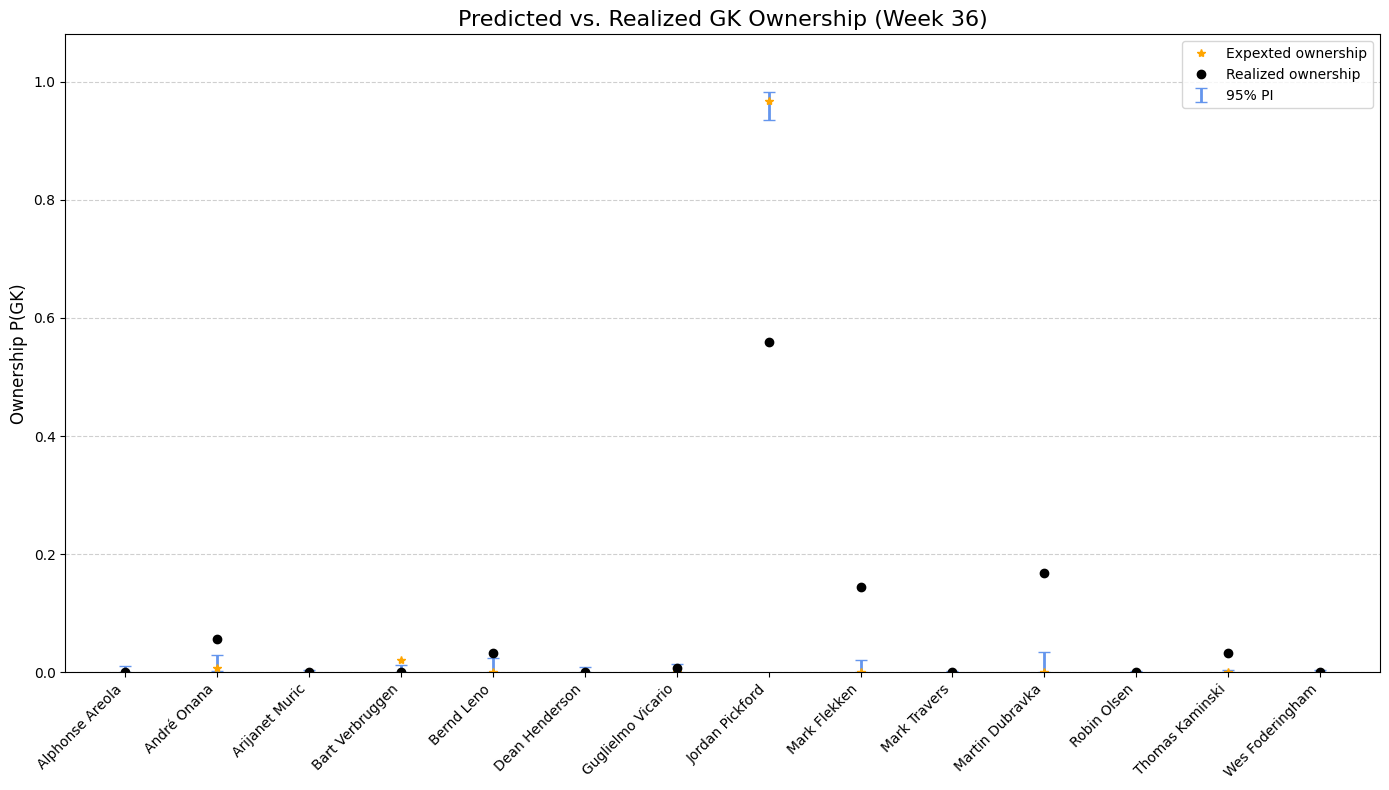

In [1020]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []


for i in range(num_samples):
    beta_sample = beta_gk[i]

    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[0], beta_gk))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)


# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# Ensure valid intervals
lower_bounds = np.minimum(lower_bounds, mean_preds)
upper_bounds = np.maximum(upper_bounds, mean_preds)


y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))
# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=gk_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expexted ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 43 posterior samples for beta.


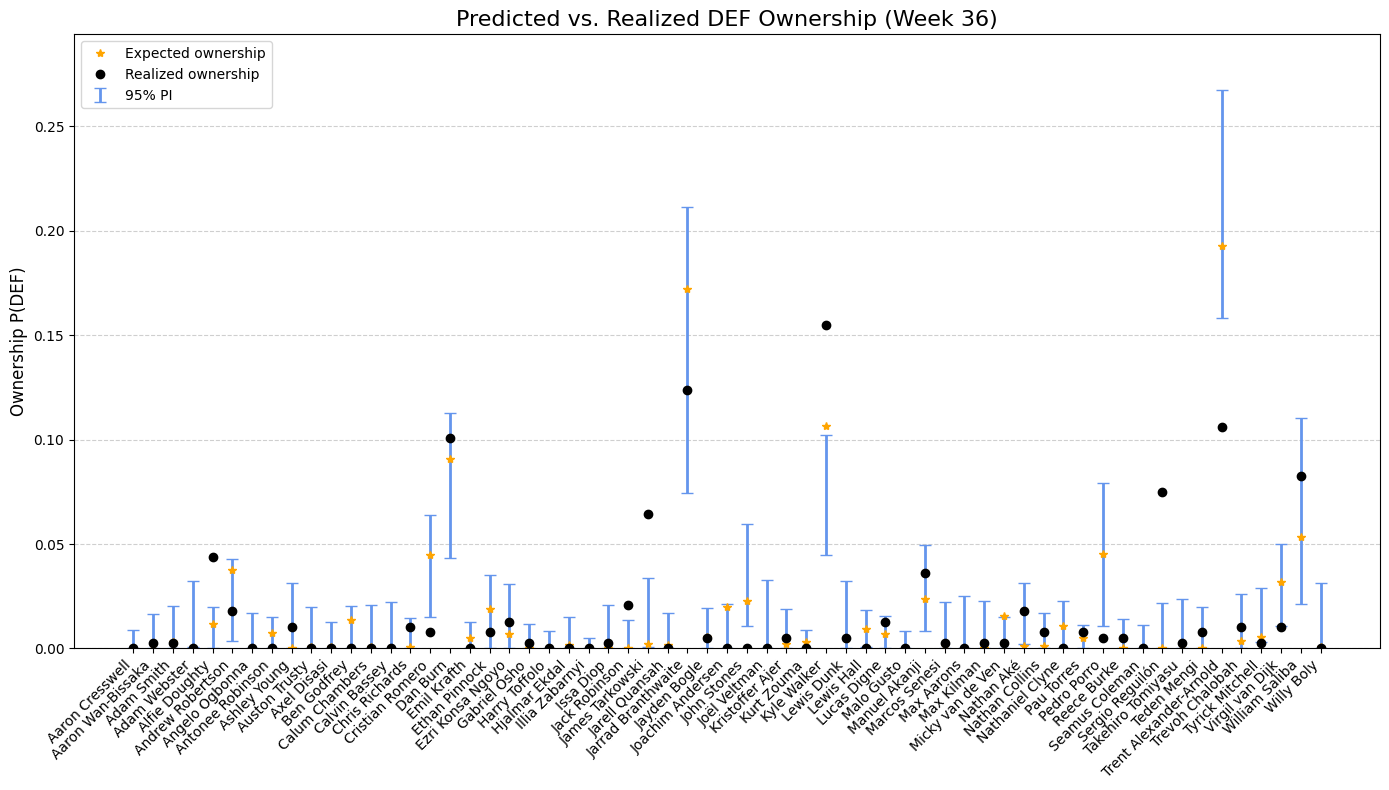

In [1021]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_def[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[1], beta_def))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)


# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# Ensure valid intervals
lower_bounds = np.minimum(lower_bounds, mean_preds)
upper_bounds = np.maximum(upper_bounds, mean_preds)


y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=def_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the expected ownership as black dots on top
plt.plot(
    def_names,
    def_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expected ownership'
)


# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 41 posterior samples for beta.
(41, 89)
(89,) (89,)


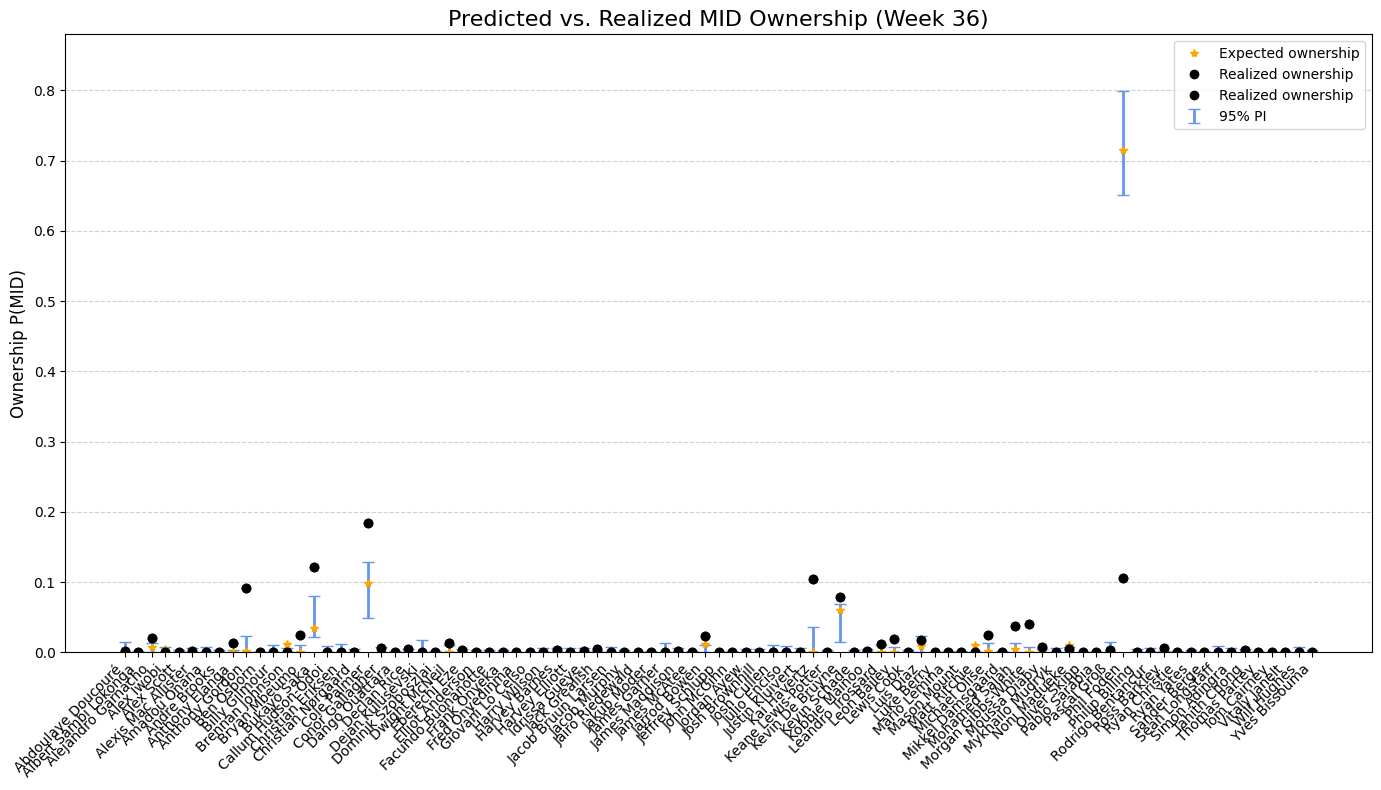

In [1022]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_mid[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[2], beta_mid))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)
print(predictions_array.shape)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# Ensure valid intervals
lower_bounds = np.minimum(lower_bounds, mean_preds)
upper_bounds = np.maximum(upper_bounds, mean_preds)


y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

# Plot the 95% Prediction Intervals as blue error bars
print(mid_names.shape, mean_preds.shape)
plt.errorbar(
    x=mid_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)
# Plot the expected ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expected ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(MID)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 40 posterior samples for beta.


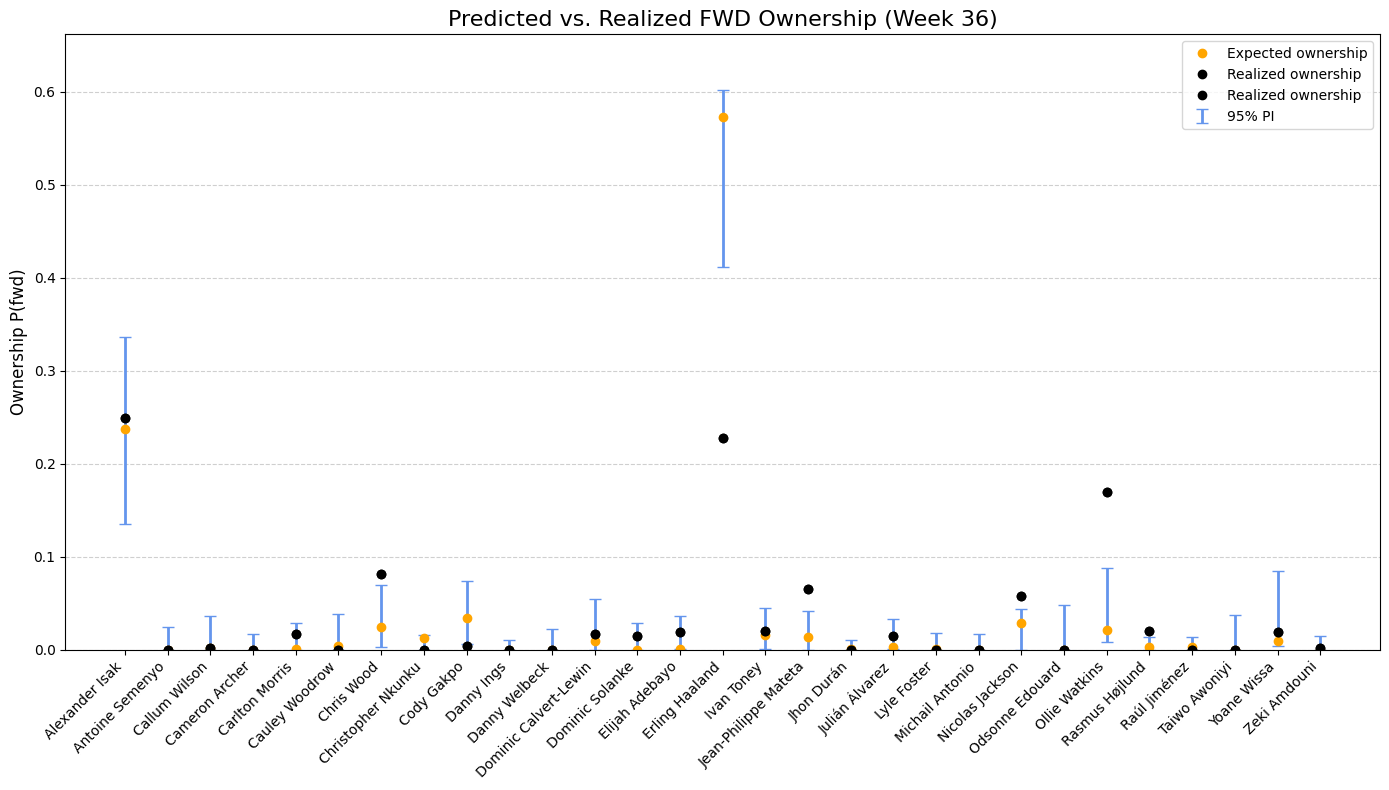

In [1023]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_fwd[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[3], beta_fwd))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# Ensure valid intervals
lower_bounds = np.minimum(lower_bounds, mean_preds)
upper_bounds = np.maximum(upper_bounds, mean_preds)


y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=fwd_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the expected ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_est,
    'o',
    color='orange',
    markersize=6,
    label='Expected ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(fwd)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [1024]:
# --- Step 19: Return W_op ---
# Generate O opponent portfolios[span_17](end_span)
generated_portfolios = sample_opponent_portfolios(
    O=200,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    costs=prices,
    budget=100,
    teams=teams,
    xp_preds=xPts
)

# prices[3].shape


Generating 200 opponent portfolios...
91.2
--------------------------->>>>>>>> 1
91.89999999999999
--------------------------->>>>>>>> 2
90.7
--------------------------->>>>>>>> 3
90.2
--------------------------->>>>>>>> 4
95.2
--------------------------->>>>>>>> 5
90.1
--------------------------->>>>>>>> 6
93.0
--------------------------->>>>>>>> 7
90.0
--------------------------->>>>>>>> 8
93.8
--------------------------->>>>>>>> 9
91.2
--------------------------->>>>>>>> 10
91.0
--------------------------->>>>>>>> 11
90.6
--------------------------->>>>>>>> 12
91.60000000000001
--------------------------->>>>>>>> 13
90.0
--------------------------->>>>>>>> 14
93.20000000000002
--------------------------->>>>>>>> 15
90.7
--------------------------->>>>>>>> 16
90.60000000000001
--------------------------->>>>>>>> 17
93.10000000000001
--------------------------->>>>>>>> 18
90.0
--------------------------->>>>>>>> 19
94.0
--------------------------->>>>>>>> 20
90.4
--------------------

In [1025]:
Wo_ = []
for i in generated_portfolios:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in valid_player_ids])
    Wo_.append(squad)

Output()

Finished [100%]: Average Loss = 17,205
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.856,0.020,4.817,4.893,0.001,0.000,888.0,990.0,NaN
delta[1],0.723,0.018,0.692,0.757,0.001,0.000,1011.0,992.0,NaN
delta[2],5.838,0.022,5.792,5.877,0.001,0.000,1164.0,957.0,NaN
delta[3],5.092,0.020,5.054,5.130,0.001,0.000,947.0,868.0,NaN
delta[4],0.453,0.018,0.418,0.486,0.001,0.000,831.0,837.0,NaN
...,...,...,...,...,...,...,...,...,...
G_r[177],43.663,0.070,43.529,43.796,0.002,0.002,1051.0,927.0,NaN
G_r[178],42.724,0.069,42.598,42.857,0.002,0.002,1008.0,955.0,NaN
G_r[179],45.130,0.075,44.994,45.276,0.002,0.002,1038.0,1068.0,NaN
G_r[180],40.892,0.071,40.767,41.031,0.002,0.002,1034.0,972.0,NaN


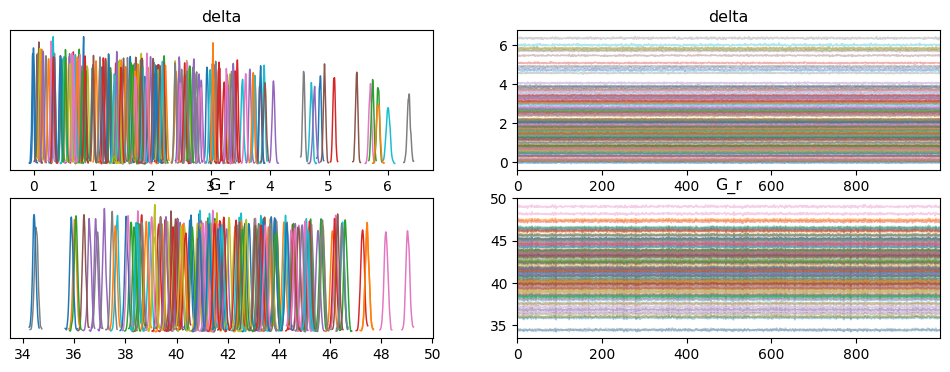

In [1026]:
def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter


def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [1027]:
delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90, axis=1)  # shape (N_samples,)
print(G_r_scalar.shape, delta_samples.shape)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_scalar)


(1000,) (1000, 195)


(1000, 195) (1000,)


In [1028]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, ids)
selected, player_names, total_points

195 195
195 195 {'Brentford', 'Crystal Palace', 'Liverpool', 'Manchester United', 'Burnley', 'Chelsea', 'Wolverhampton Wanderers', 'Brighton and Hove Albion', 'Tottenham Hotspur', 'Arsenal', 'Newcastle United', 'Fulham', 'Manchester City', 'West Ham United', 'Nottingham Forest', 'Aston Villa', 'Everton', 'Bournemouth', 'Sheffield United', 'Luton'}
Brentford [33, 46, 68, 71, 84, 114, 116, 118, 134, 144, 150, 187, 192] 13 195
Crystal Palace [43, 56, 63, 89, 99, 100, 102, 105, 141, 151, 154, 185, 189] 13 195
Liverpool [11, 16, 48, 61, 79, 95, 127, 145, 183, 186] 10 195
Manchester United [1, 6, 17, 45, 117, 137, 163, 174] 8 195
Burnley [23, 80, 87, 107, 108, 129, 171, 194] 8 195
Chelsea [26, 47, 50, 130, 148, 152, 153, 184] 8 195
Wolverhampton Wanderers [133, 140, 157] 3 195
Brighton and Hove Albion [4, 27, 31, 55, 70, 90, 109, 110, 124, 158, 175] 11 195
Tottenham Hotspur [7, 51, 58, 74, 75, 92, 143, 155, 160, 167, 193] 11 195
Arsenal [34, 57, 113, 121, 178, 181, 190] 7 195
Newcastle Unite

([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 76)

# GW 37


In [1029]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_37.csv', index_col=0)
# Check if teams match
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]

players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_37 = data_23_24[data_23_24['event'] < 37]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')


## Generate Cov_Mat


In [1030]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_37)
# cov_mat

Starting to optimize team selection...
(204, 189)
(5232, 180)
(204,) (204,) (204, 204)


## Data Preparations


In [1031]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

gk_data = players_preds[players_preds['position'] == 'GK'][data_cols_gk].dropna()
def_data = players_preds[players_preds['position'] == 'DEF'][data_cols].dropna()
mid_data = players_preds[players_preds['position'] == 'MID'][data_cols].dropna()
fwd_data = players_preds[players_preds['position'] == 'FWD'][data_cols].dropna()
data = [gk_data, def_data, mid_data, fwd_data]

player_ids = np.concatenate([gk_data['fpl_id'].to_list(), def_data['fpl_id'].to_list(), mid_data['fpl_id'].to_list(),  fwd_data['fpl_id'].to_list()])

gk_data.drop(columns='fpl_id', inplace=True)
def_data.drop(columns='fpl_id', inplace=True)
mid_data.drop(columns='fpl_id', inplace=True)
fwd_data.drop(columns='fpl_id', inplace=True)

data_cols.remove('fpl_id')
data_cols_gk.remove('fpl_id')

data_23_24_36 = data_23_24_36[data_23_24_36['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca = clean_data(players_preds, valid_player_ids)

starting to clean data...
0      530
1      401
2      249
3       84
4      153
      ... 
199    592
200    119
201     58
202    493
203    594
Name: fpl_id, Length: 204, dtype: int64
(204, 189) 204
data successfully cleaned...


In [1032]:
ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
gk_probs_obs = ownership_gk / ownership_gk.sum()

ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
def_probs_obs = ownership_def / ownership_def.sum()

cols = data_cols.copy()
cols.append('ownership_percent')
cols.append('FPL_Name')

mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
ownership_mid = mids['ownership_percent']
mid_names = mids['FPL_Name']
mid_probs_obs = ownership_mid / ownership_mid.sum()

fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
ownership_fwds = fwds['ownership_percent']
fwd_names = fwds['FPL_Name']
fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [1033]:
alphas = {
        'GK': np.exp(np.dot(X_pca[0], beta_gk)),
        'DEF': np.exp(np.dot(X_pca[1], beta_def)),
        'MID': np.exp(np.dot(X_pca[2], beta_mid)),
        'FWD': np.exp(np.dot(X_pca[3], beta_fwd))
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}

gk_probs_est = p_vectors['GK'].tolist()
def_probs_est = p_vectors['DEF'].tolist()
mid_probs_est = p_vectors['MID'].tolist()
fwd_probs_est = p_vectors['FWD'].tolist()


## Plots


Extracted 36 posterior samples for beta.


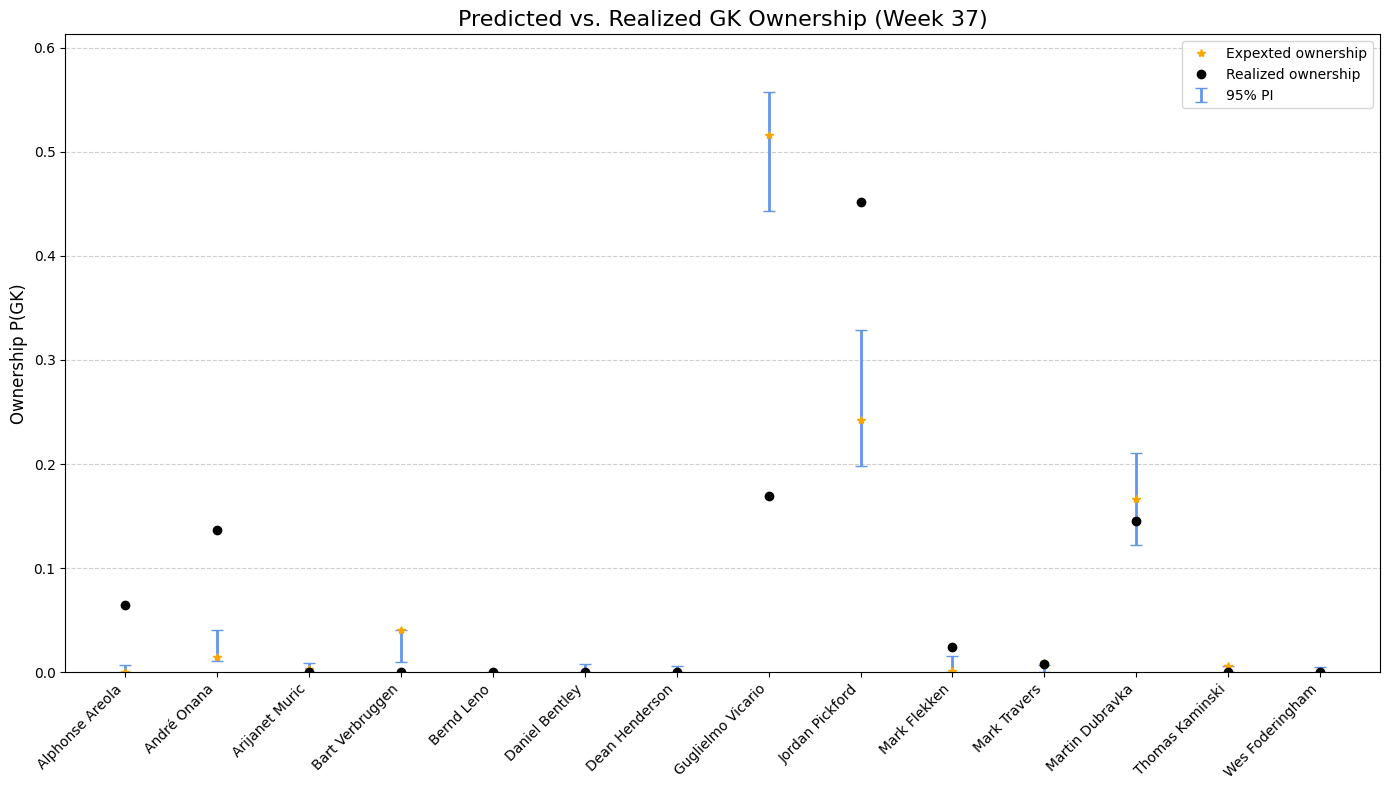

In [1034]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []


for i in range(num_samples):
    beta_sample = beta_gk[i]

    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[0], beta_gk))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center


# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))
y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]


# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=gk_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expexted ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 43 posterior samples for beta.


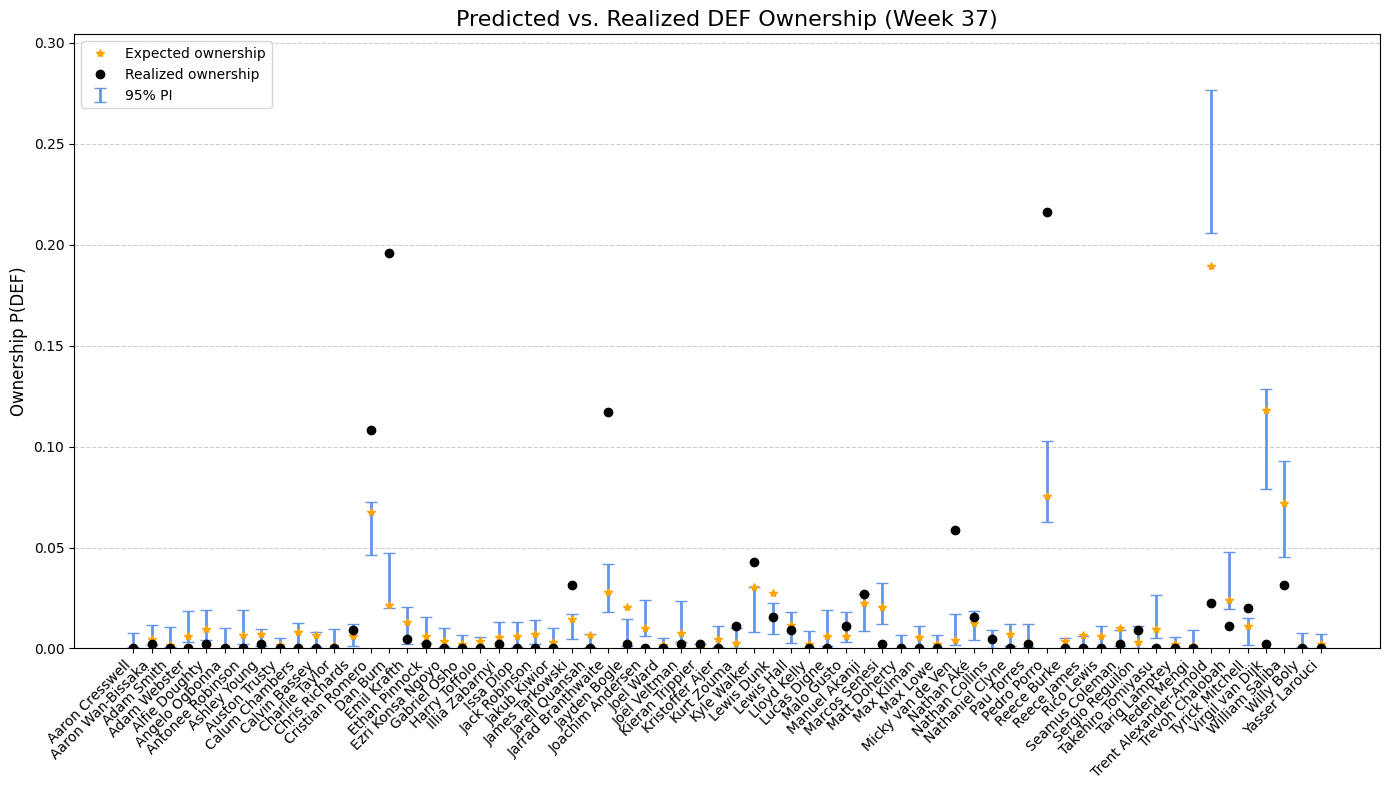

In [1035]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_def[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[1], beta_def))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)


# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

y_err = [
    mean_preds - lower_bounds,
    upper_bounds - mean_preds
    ]

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=def_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the expected ownership as black dots on top
plt.plot(
    def_names,
    def_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expected ownership'
)


# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 41 posterior samples for beta.
(41, 92)
(92,) (92,)


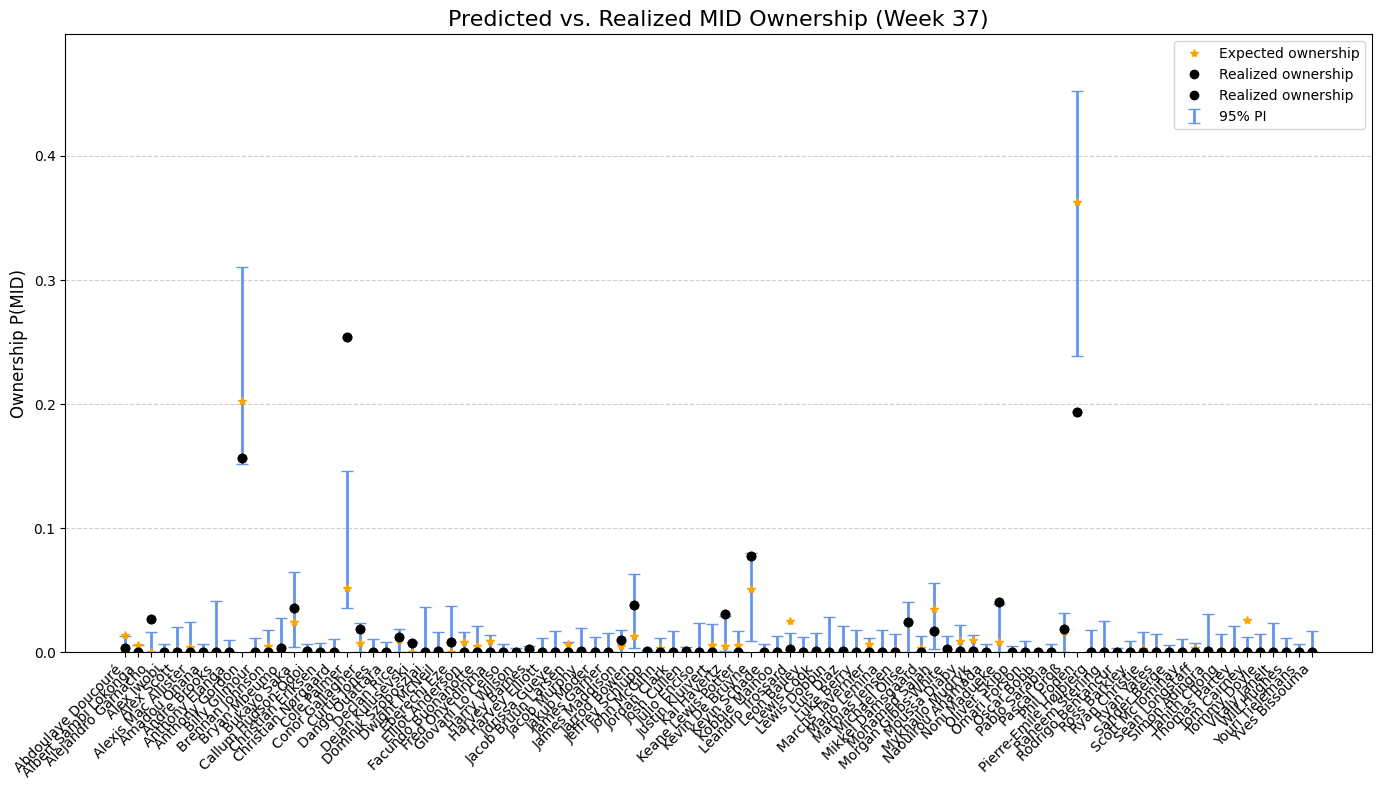

In [1036]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_mid[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[2], beta_mid))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)
print(predictions_array.shape)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center


# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))
y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# Plot the 95% Prediction Intervals as blue error bars
print(mid_names.shape, mean_preds.shape)
plt.errorbar(
    x=mid_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)
# Plot the expected ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expected ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(MID)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 40 posterior samples for beta.


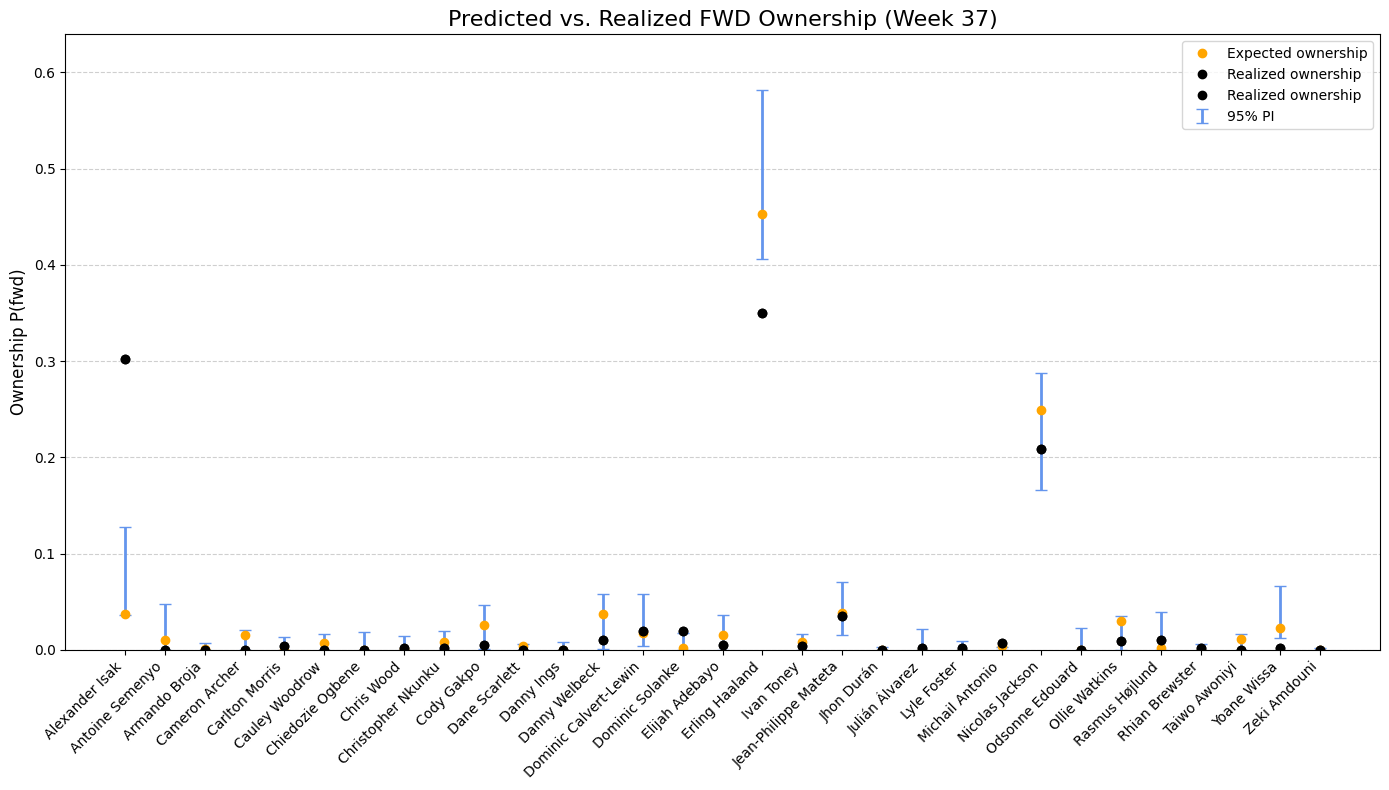

In [1037]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_fwd[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[3], beta_fwd))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center


# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))
y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=fwd_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the expected ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_est,
    'o',
    color='orange',
    markersize=6,
    label='Expected ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(fwd)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [1038]:
# --- Step 19: Return W_op ---
# Generate O opponent portfolios[span_17](end_span)
generated_portfolios = sample_opponent_portfolios(
    O=200,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    costs=prices,
    budget=100,
    teams = teams,
    xp_preds=xPts

)

# prices[3].shape


Generating 200 opponent portfolios...
93.39999999999999
--------------------------->>>>>>>> 1
90.9
--------------------------->>>>>>>> 2
91.6
--------------------------->>>>>>>> 3
91.1
--------------------------->>>>>>>> 4
90.4
--------------------------->>>>>>>> 5
90.4
--------------------------->>>>>>>> 6
91.3
--------------------------->>>>>>>> 7
91.5
--------------------------->>>>>>>> 8
91.19999999999999
--------------------------->>>>>>>> 9
91.4
--------------------------->>>>>>>> 10
90.1
--------------------------->>>>>>>> 11
91.5
--------------------------->>>>>>>> 12
91.5
--------------------------->>>>>>>> 13
93.1
--------------------------->>>>>>>> 14
92.0
--------------------------->>>>>>>> 15
90.30000000000001
--------------------------->>>>>>>> 16
91.39999999999999
--------------------------->>>>>>>> 17
91.89999999999999
--------------------------->>>>>>>> 18
90.50000000000001
--------------------------->>>>>>>> 19
90.19999999999999
--------------------------->>>>>>>> 20

In [1039]:
Wo_ = []
for i in generated_portfolios:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in valid_player_ids])
    Wo_.append(squad)

Output()

Finished [100%]: Average Loss = 17,927
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.951,0.020,4.915,4.988,0.001,0.000,974.0,915.0,NaN
delta[1],1.615,0.021,1.579,1.660,0.001,0.000,963.0,992.0,NaN
delta[2],0.771,0.018,0.741,0.805,0.001,0.000,1057.0,1017.0,NaN
delta[3],5.885,0.022,5.847,5.930,0.001,0.000,1002.0,904.0,NaN
delta[4],5.098,0.020,5.056,5.131,0.001,0.001,698.0,821.0,NaN
...,...,...,...,...,...,...,...,...,...
G_r[195],34.225,0.069,34.096,34.354,0.002,0.002,839.0,780.0,NaN
G_r[196],30.146,0.068,30.026,30.274,0.002,0.002,930.0,866.0,NaN
G_r[197],25.832,0.064,25.712,25.950,0.002,0.002,881.0,1071.0,NaN
G_r[198],26.437,0.066,26.313,26.555,0.002,0.002,845.0,897.0,NaN


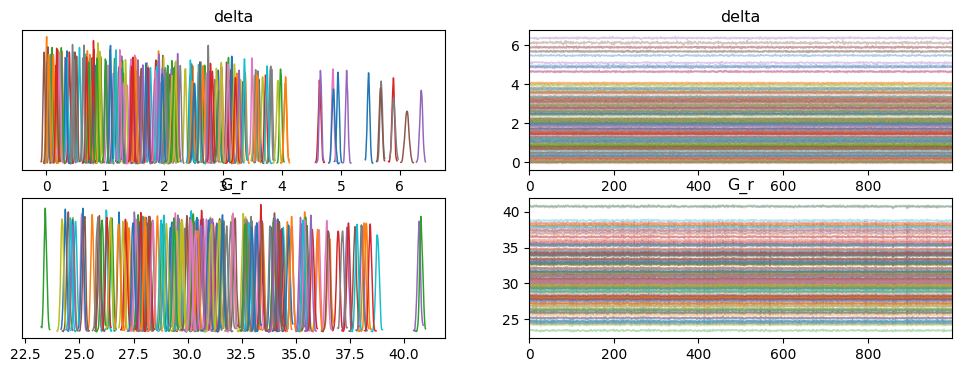

In [1040]:
def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter

def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [1041]:
delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90, axis=1)  # shape (N_samples,)
print(G_r_scalar.shape, delta_samples.shape)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_scalar)


(1000,) (1000, 204)
(1000, 204) (1000,)


In [1042]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, ids)
selected, player_names, total_points

204 204
204 204 {'Brentford', 'Crystal Palace', 'Liverpool', 'Manchester United', 'Burnley', 'Chelsea', 'Wolverhampton Wanderers', 'Brighton and Hove Albion', 'Tottenham Hotspur', 'Arsenal', 'Newcastle United', 'Fulham', 'Manchester City', 'West Ham United', 'Nottingham Forest', 'Aston Villa', 'Everton', 'Bournemouth', 'Sheffield United', 'Luton'}
Brentford [29, 42, 67, 82, 109, 111, 114, 133, 136, 143, 150, 194, 200] 13 204
Crystal Palace [39, 55, 62, 95, 96, 98, 99, 140, 148, 151, 154, 192, 196] 13 204
Liverpool [10, 44, 48, 60, 77, 91, 125, 144, 190, 193] 10 204
Manchester United [1, 6, 15, 41, 113, 157, 166, 176, 179] 9 204
Burnley [21, 37, 84, 103, 127, 175, 203] 7 204
Chelsea [22, 43, 46, 78, 128, 147, 152, 153, 165, 168, 191] 11 204
Wolverhampton Wanderers [52, 132, 137, 138, 159, 189] 6 204
Brighton and Hove Albion [4, 25, 27, 54, 69, 87, 104, 105, 121, 160, 180, 184] 12 204
Tottenham Hotspur [47, 50, 57, 72, 73, 89, 142, 155, 162, 164, 171, 202] 12 204
Arsenal [30, 56, 86, 108

([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 55)

In [1043]:
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, ids)
selected, player_names, total_points,1.5* 2+ 6+ 2+ 8+ 5+ 6+ 2+ 5+ 2*9+ 1+ 9

[2 6 2 8 5 6 2 5 9 1 9] [4.00510161 3.41600723 3.20246962 1.906      2.76811747 1.80099999
 2.90345529 3.5959465  4.91468495 1.21157122 0.58862385]


([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 55,
 65.0)

# GW 38


In [1044]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_38.csv', index_col=0)
# Check if teams match
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]

players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_38 = data_23_24[data_23_24['event'] < 38]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')


## Generate Cov_Mat


In [1045]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_38)
# cov_mat

Starting to optimize team selection...
(196, 189)
(5236, 180)
(196,) (196,) (196, 196)


## Data Preparations


In [1046]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

gk_data = players_preds[players_preds['position'] == 'GK'][data_cols_gk].dropna()
def_data = players_preds[players_preds['position'] == 'DEF'][data_cols].dropna()
mid_data = players_preds[players_preds['position'] == 'MID'][data_cols].dropna()
fwd_data = players_preds[players_preds['position'] == 'FWD'][data_cols].dropna()
data = [gk_data, def_data, mid_data, fwd_data]

player_ids = np.concatenate([gk_data['fpl_id'].to_list(), def_data['fpl_id'].to_list(), mid_data['fpl_id'].to_list(),  fwd_data['fpl_id'].to_list()])

gk_data.drop(columns='fpl_id', inplace=True)
def_data.drop(columns='fpl_id', inplace=True)
mid_data.drop(columns='fpl_id', inplace=True)
fwd_data.drop(columns='fpl_id', inplace=True)

data_cols.remove('fpl_id')
data_cols_gk.remove('fpl_id')

data_23_24_36 = data_23_24_36[data_23_24_36['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca = clean_data(players_preds, valid_player_ids)

starting to clean data...
0      530
1      401
2      249
3       84
4      153
      ... 
191     20
192    439
193    119
194    493
195    594
Name: fpl_id, Length: 196, dtype: int64
(196, 189) 196
data successfully cleaned...


In [1047]:
ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
gk_probs_obs = ownership_gk / ownership_gk.sum()

ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
def_probs_obs = ownership_def / ownership_def.sum()

cols = data_cols.copy()
cols.append('ownership_percent')
cols.append('FPL_Name')

mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
ownership_mid = mids['ownership_percent']
mid_names = mids['FPL_Name']
mid_probs_obs = ownership_mid / ownership_mid.sum()

fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
ownership_fwds = fwds['ownership_percent']
fwd_names = fwds['FPL_Name']
fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [1048]:
alphas = {
        'GK': np.exp(np.dot(X_pca[0], beta_gk)),
        'DEF': np.exp(np.dot(X_pca[1], beta_def)),
        'MID': np.exp(np.dot(X_pca[2], beta_mid)),
        'FWD': np.exp(np.dot(X_pca[3], beta_fwd))
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}

gk_probs_est = p_vectors['GK'].tolist()
def_probs_est = p_vectors['DEF'].tolist()
mid_probs_est = p_vectors['MID'].tolist()
fwd_probs_est = p_vectors['FWD'].tolist()


## Plots


Extracted 36 posterior samples for beta.


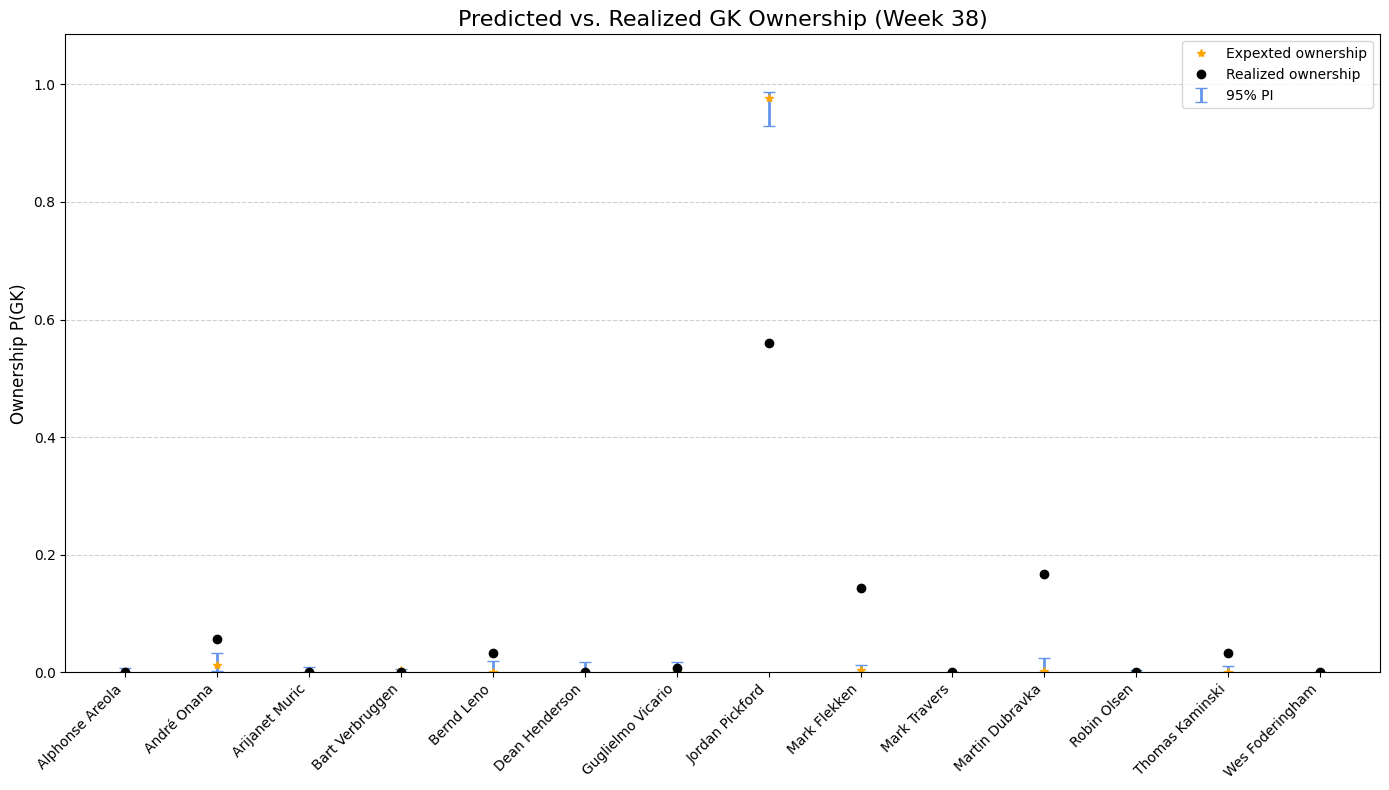

In [1049]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []


for i in range(num_samples):
    beta_sample = beta_gk[i]
    alpha_sample = np.exp(np.dot(X_pca[0], beta_gk))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# Ensure valid intervals
lower_bounds = np.minimum(lower_bounds, mean_preds)
upper_bounds = np.maximum(upper_bounds, mean_preds)

y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=gk_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expexted ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 43 posterior samples for beta.


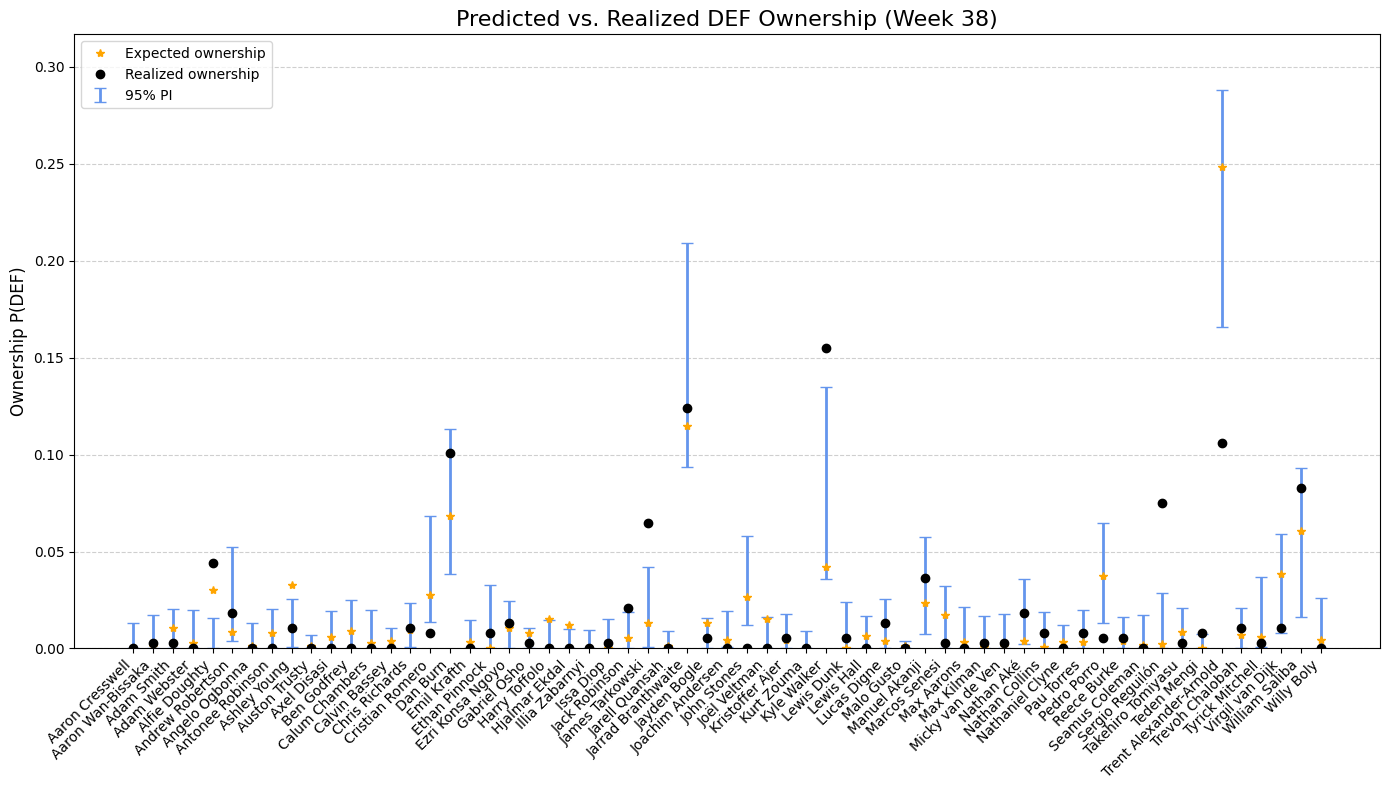

In [1050]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_def[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[1], beta_def))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)


# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# # --- 5. Plot the Results ---
# plt.figure(figsize=(14, 8))

# y_err = [
#     mean_preds - lower_bounds,
#     upper_bounds - mean_preds
#     ]

# Ensure valid intervals
lower_bounds = np.minimum(lower_bounds, mean_preds)
upper_bounds = np.maximum(upper_bounds, mean_preds)


y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=def_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the expected ownership as black dots on top
plt.plot(
    def_names,
    def_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expected ownership'
)


# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 41 posterior samples for beta.
(41, 89)
(89,) (89,)


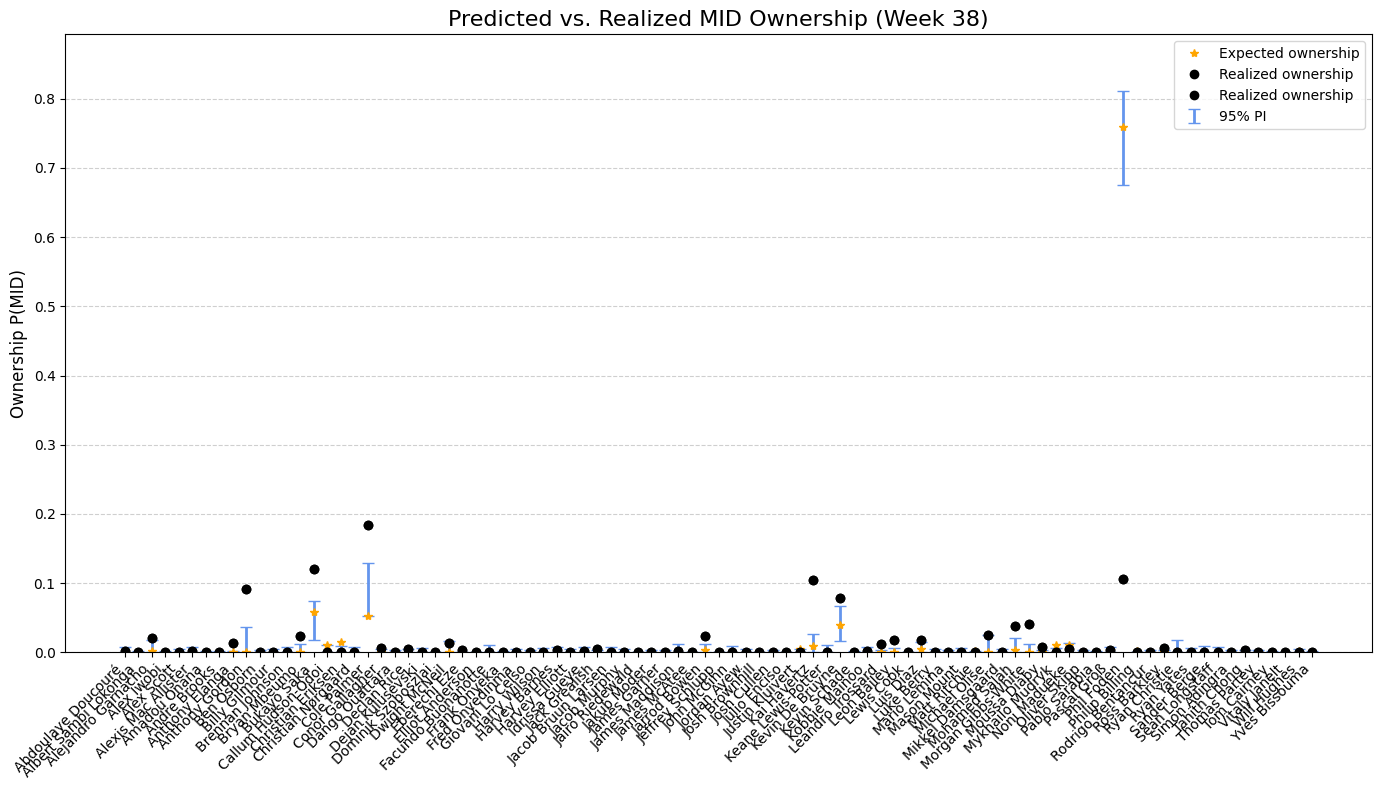

In [1051]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_mid[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[2], beta_mid))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)
print(predictions_array.shape)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# Ensure valid intervals
lower_bounds = np.minimum(lower_bounds, mean_preds)
upper_bounds = np.maximum(upper_bounds, mean_preds)


y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

# Plot the 95% Prediction Intervals as blue error bars
print(mid_names.shape, mean_preds.shape)
plt.errorbar(
    x=mid_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)
# Plot the expected ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expected ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(MID)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 40 posterior samples for beta.


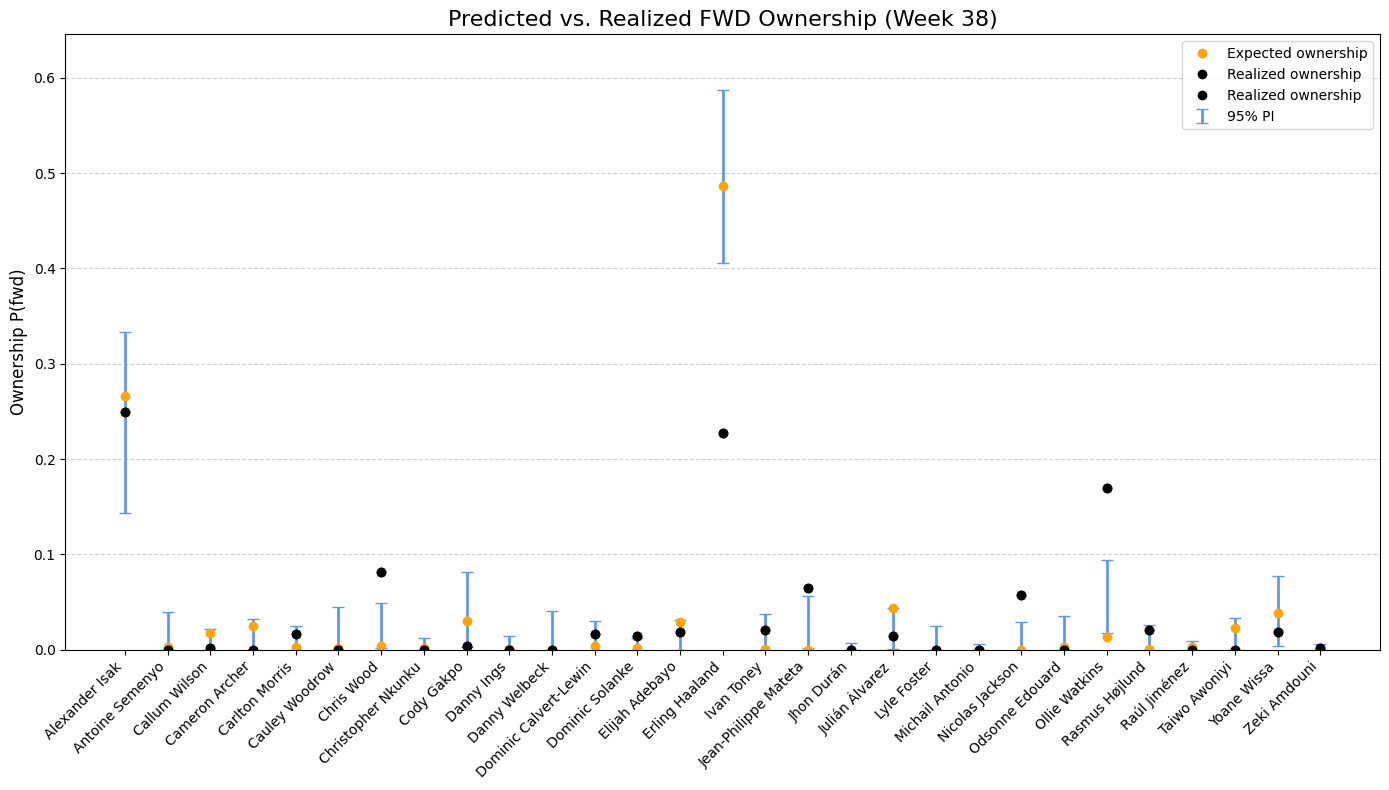

In [1052]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_fwd[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[3], beta_fwd))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# Ensure valid intervals
lower_bounds = np.minimum(lower_bounds, mean_preds)
upper_bounds = np.maximum(upper_bounds, mean_preds)


y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=fwd_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the expected ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_est,
    'o',
    color='orange',
    markersize=6,
    label='Expected ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(fwd)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [1053]:
# --- Step 19: Return W_op ---
# Generate O opponent portfolios[span_17](end_span)
generated_portfolios = sample_opponent_portfolios(
    O=200,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    costs=prices,
    budget=100,
    teams = teams,
    xp_preds=xPts

)


# prices[3].shape


Generating 200 opponent portfolios...
90.7
--------------------------->>>>>>>> 1
91.10000000000001
--------------------------->>>>>>>> 2
90.7
--------------------------->>>>>>>> 2
90.1
--------------------------->>>>>>>> 3
90.2
--------------------------->>>>>>>> 4
90.5
--------------------------->>>>>>>> 5
91.7
--------------------------->>>>>>>> 6
90.30000000000001
--------------------------->>>>>>>> 7
91.60000000000001
--------------------------->>>>>>>> 8
90.0
--------------------------->>>>>>>> 9
94.30000000000001
--------------------------->>>>>>>> 10
90.1
--------------------------->>>>>>>> 11
90.60000000000001
--------------------------->>>>>>>> 12
92.9
--------------------------->>>>>>>> 13
90.0
--------------------------->>>>>>>> 14
90.3
--------------------------->>>>>>>> 15
91.2
--------------------------->>>>>>>> 16
90.2
--------------------------->>>>>>>> 17
90.1
--------------------------->>>>>>>> 18
92.9
--------------------------->>>>>>>> 19
91.0
---------------------

In [1054]:
Wo_ = []
for i in generated_portfolios:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in valid_player_ids])
    Wo_.append(squad)

In [ ]:


def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
az.summary(MC_sim_trace, var_names=["delta", "G_r"])

Output()

In [ ]:
delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90, axis=1)  # shape (N_samples,)
print(G_r_scalar.shape, delta_samples.shape)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_scalar)


(1000,) (1000, 196)
(1000, 196) (1000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, ids)
selected, player_names, total_points

196 196
196 196 {'Brentford', 'Crystal Palace', 'Liverpool', 'Manchester United', 'Burnley', 'Chelsea', 'Wolverhampton Wanderers', 'Brighton and Hove Albion', 'Tottenham Hotspur', 'Arsenal', 'Newcastle United', 'Fulham', 'Manchester City', 'West Ham United', 'Nottingham Forest', 'Aston Villa', 'Everton', 'Bournemouth', 'Sheffield United', 'Luton'}
Brentford [33, 46, 68, 71, 84, 114, 116, 118, 134, 144, 150, 188, 193] 13 196
Crystal Palace [43, 56, 63, 89, 99, 100, 102, 105, 141, 151, 154, 186, 190] 13 196
Liverpool [11, 16, 48, 61, 79, 95, 127, 145, 176, 184, 187] 11 196
Manchester United [1, 6, 17, 45, 117, 137, 163, 174] 8 196
Burnley [23, 80, 87, 107, 108, 129, 171, 195] 8 196
Chelsea [26, 47, 50, 130, 148, 152, 153, 185] 8 196
Wolverhampton Wanderers [133, 140, 157] 3 196
Brighton and Hove Albion [4, 27, 31, 55, 70, 90, 109, 110, 124, 158, 175] 11 196
Tottenham Hotspur [7, 51, 58, 74, 75, 92, 143, 155, 160, 167, 194] 11 196
Arsenal [34, 57, 113, 121, 179, 182, 191] 7 196
Newcastle 

([19, 20, 60, 263, 308, 341, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Manuel Akanji',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 77)

In [ ]:
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, ids)
selected, player_names, total_points

[10  8 21  3  5  2  2 13  2  5  6] [8.42857821 5.75904691 9.66969921 2.348      2.83085205 5.88199999
 1.23239887 4.82644648 2.12951213 3.48122268 5.19414667]


([19, 20, 60, 263, 308, 341, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Manuel Akanji',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 77)

In [ ]:
fgo_managers = pd.read_csv('../FPL predictors/Fantasy Go/fgo_managers.csv')
fgo_38 = fgo_managers[fgo_managers['gameweek'] == 37]
fgo_38[['manager', 'entry','points', 'prize', 'pick']]

,manager,entry,points,prize,pick
9514,Mr.2,1,140 Points,"R 3,890.25","[{'player_name': 'Dubravka', 'points': '5', 'p..."
9515,steezy_striker,2,138 Points,"R 1,695.75","[{'player_name': 'Vicario', 'points': '4', 'po..."
9516,MESSITHEGOAT,9,136.5 Points,"R 1,097.25","[{'player_name': 'Onana', 'points': '5', 'posi..."
9517,sakhumzi99,1,133 Points,R 460.75,"[{'player_name': 'Dubravka', 'points': '5', 'p..."
9518,theezkeeyz,2,133 Points,R 460.75,"[{'player_name': 'Pickford', 'points': '8', 'p..."
...,...,...,...,...,...
9752,unathi12,3,60 Points,NaN,"[{'player_name': 'Pickford', 'points': '8', 'p..."
9753,ialreadywonbruv,5,57.5 Points,NaN,"[{'player_name': 'Pickford', 'points': '8', 'p..."
9754,ialreadywonbruv,4,49.5 Points,NaN,"[{'player_name': 'Onana', 'points': '5', 'posi..."
9755,Frankenstein 🧟‍♂️,1,34.5 Points,NaN,"[{'player_name': 'Pickford', 'points': '8', 'p..."
